# Example: Excition diffusion as a function of excitation power

We pump the sample with increasing optical power and analyse how the exciton cloud moves. We track the centroid position as well as the excition area.

In [2]:
import numpy as np
from tmdc_optics_tools import diffusion, plotting
from tmdc_optics_tools.loaders import AttoCubePLScanRealSpace, AttoCubePLVabScan
from tmdc_optics_tools.plotting import (
    ImageSequencePanel,
    DiffusionCloudPanel,
    animate_panels,
)

We load our real-space PL map scans and the spectral file from the AttoCube setup.

In [5]:
scan = AttoCubePLScanRealSpace(path = "./data/exciton-diffusion", prefix = "power_dep_")
scan_spectra = AttoCubePLVabScan(path = "./data/exciton-diffusion/power_dep_26_06_30_15_24_38_iter_0.csv")
power_sweep = scan_spectra.power # gives us the excitation power

We first test out the processing function. We can also plot our `roi` and `bg_region` to be applied to the images. The `roi` effectively crops the region in which the solver looks for the excition center of mass in pixel space. The `bg_region` argument indicates the region over which the solver should look at for the background counts. In this case, the solver uses the median of the background region as the background counts, which makes this more robust to fluctuations due to cosmic rays.

In [6]:
result = diffusion.analyse_diffusion_cloud(
    scan.load_frame(15),
    threshold   = "otsu",      # or e.g. 0.15 (fraction of max)
    smooth_sigma= 1.0,
    pixel_scale = None,        # set to e.g. 0.065 when calibrated
    origin      = "corner",    # change to "center" or "image_center" later
)

print(result)

DiffusionResult
  Centroid (px)   : (269.27, 228.35)
  Area            : 3921.0 px²
  Threshold       : 230
  Contours        : 30


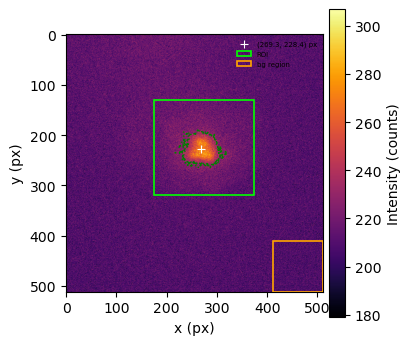

In [7]:
fig, ax, result = plotting.plot_diffusion_cloud(scan.load_frame(15), result = result, show_roi = True, show_bg_region = True, bg_region = (slice(412, 512), slice(412, 512)), roi = (slice(130, 320), slice(175, 375)),)

Now we look at the entire image sequence.

In [8]:
seq = diffusion.analyse_diffusion_sequence(
    scan,
    pixel_scale = 0.065,       # µm/px
    origin      = "corner",    # switch to "center" / "image_center" any time
    var_array   = power_sweep,
    var_label   = "Power",
    var_units   = "µW",
    threshold  = 0.4,  
    bg_region = (slice(412, 512), slice(412, 512)),
    roi = (slice(130, 320), slice(175, 375))
)

print(seq)

DiffusionSequenceResult — 18 frames
  x_pixel range : 268.96 – 270.31
  y_pixel range : 228.37 – 231.18
  area range    : 2046.0 – 2701.0 px²


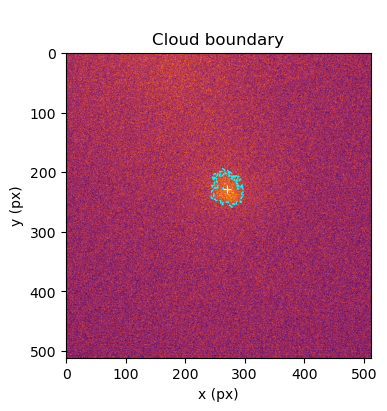

In [11]:
panels = [
    DiffusionCloudPanel(scan, seq_result=seq, title="Cloud boundary"),
]
fig, anim = animate_panels(panels)